<a href="https://colab.research.google.com/github/nhatminhvu146-cmyk/project/blob/main/Robot_Fleet_Health_Classification_Project_%5BHackathon_Project%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Hackathon Project**

The Story

You are a data scientist at RoboOps, a fleet management software company. Their clients run humanoid robot fleets in warehouses and factories. Every night, the system runs a full diagnostic on each robot and saves the results. You receive all that overnight data every morning, and your model must classify each robot before the workers arrive at 6 am.

The shift manager uses your model output to decide which robots go to which tasks and which robots stay offline today.

Your task is to predict the deployment status for each robot in the test set.

Motivation for the Problem Statement

Why This Problem is Relevant, Important, and Worth Solving in 2026

1. The Humanoid Robot Market

Humanoid robots are being deployed in warehouses and factories all over the world, and the market is one of the fastest-growing in the world. The global humanoid robot market is projected to grow to USD 15.26 billion by 2030 at a CAGR of 39.2% (Source: MarketsandMarkets). The demand driving this market on the other hand, is structural, not just speculative. Demographic changes in advanced economies could lead to labor shortages as working-age populations decline by up to 25%, a shortage of 2.1 million US manufacturing workers is projected by 2030, and companies deploying warehouse automation already report 25 to 30 percent reductions in labor costs and accuracy rates approaching 99% (Source: Bain and Company). These are not trends tied to any single company or product launch. They are the forces that will keep humanoid robot adoption growing for the rest of the decade.

2. Why Classifying Robots Before Deployment Matters

Sending an unhealthy robot into a live shift is a serious financial risk. Robot downtime can cost anywhere between USD 1,000 to 10,000 per minute, and unplanned downtime costs 15 times more than planned downtime. Across industries, Fortune Global 500 companies lose USD 1.4 trillion every year to unplanned equipment failures (Source: Siemens True Cost of Downtime 2024). The good news is that 42% of all unplanned downtime comes from equipment failure, and failing equipment almost always shows warning signs beforehand (Source: Manufacturing Downtime Statistics). A correct pre-shift classification turns an expensive unplanned failure into a simple planned decision.

3. Why Machine Learning and Why Tabular Data

Every robot produces one structured row of diagnostic data per night. Battery levels, joint readings, sensor error counts, temperature, and fault flags. This is classic tabular data. No images, no text, no time series. The patterns that separate a healthy robot from one about to fail are non-linear and multi-feature. A slightly elevated temperature alone means nothing. The same reading, combined with increasing torque variance and two consecutive sensor flags, is a serious warning. There are currently no widespread rule-based systems to capture such patterns, and if there were, the pattern of this data calls for a trained ML classifier that can learn directly from months of historical diagnostic data and past deployment outcomes. Tree-based ML models like Random Forests and Gradient Boosting are interpretable, accurate, and fast enough to score an entire fleet before 6 am.

Target Variable

The target variable is an integer between 1 and 7 representing the following classes.

Under Maintenance - Robot is with an engineer today, not available for work

Not Ready - Something is seriously wrong, do not deploy

Degraded - In bad shape, light tasks only

Caution - Something seems off, use carefully

Standard - Working normally

High Performance - Working very well today

Peak Condition - Perfectly healthy, best tasks only


Dataset

The problem consists of 2 separate files: Train data and Test data.

Train data has information related to each robot including overnight sensor readings, maintenance history, and performance metrics from the past 7 days. The train data also includes the correct deployment status label for each robot. The training set can be used to build your machine learning model.

Test data has the same structure as the train data but the deployment status label has been removed. You are expected to predict the deployment status for each robot in the test data.

Submission File Format

You will need to submit a CSV file with exactly 20,000 entries plus a header row. The file should have exactly two columns.

Column 1: row_id

Column 2: target, containing values between 1 and 7


Accuracy Score

Your submission will be scored on Accuracy. This is the percentage of robots you classified correctly out of the 20,000 in the test set. A score of 100 means every prediction was correct. A score of 0 means none were.

Use Macro F1 Score to evaluate your model during development

This problem has 7 classes and they are not equally represented in the data. Standard robots make up nearly 30% of the dataset. Under Maintenance robots make up only 6%. If you only track accuracy you can end up with a model that predicts common classes well and misses rare ones entirely without realising it. In a real warehouse that means broken robots going to work and unavailable robots getting assigned to shifts.

Macro F1 Score is a better development metric for this problem. It calculates an F1 score for each of the 7 classes separately and then takes an equal average across all of them. Every class counts the same regardless of how many robots are in it. A model that scores 0.99 on Standard but 0.0 on Under Maintenance will get a poor Macro F1 even if its accuracy looks reasonable. This forces you to build a model that works across the full range of classes, not just the ones with the most training examples.

We recommend tracking Macro F1 as your primary measure of progress throughout development. Here is a sample of how you can calculate it in your notebook.

from sklearn.metrics import f1_score

# y_true  : actual target values from the solution file

# y_pred  : predictions from your model

score = f1_score(y_true, y_pred, average='macro')

print(f'Macro F1 Score: {score:.4f}')

Track this score as you make changes to your model. If your Macro F1 is improving your model is genuinely getting better across all 7 classes. If only your accuracy is improving you may be getting better at common classes while losing ground on the rare ones.

Your final leaderboard position is determined by Accuracy Score. A model built and evaluated using Macro F1 will almost always produce a better accuracy score on submission than one built using accuracy alone.

## Importing necessary libraries and data

****

In [ ]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer          # handle missing values (joint_torque_variance)

# Model evaluation
from sklearn.metrics import (
    f1_score, make_scorer, classification_report, confusion_matrix, accuracy_score
)

# models
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
!pip install catboost
from catboost import CatBoostClassifier
import catboost as cb
from sklearn.ensemble import ExtraTreesClassifier

# Handling class imbalance
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [ ]:
# mount the file
from google.colab import drive
drive.mount('/content/drive')
# read the train data
data_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Great Learning-MIT course /Hackathon Project/train.csv')
# read the test data
data_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Great Learning-MIT course /Hackathon Project/test.csv')


Mounted at /content/drive


## Exploratory Data Analysis (EDA)

In [ ]:
# Overall observation for the train data
# View the first five row of the train data
print("First five rows of the train data")
print(data_train.head())
# View the last five row of the train data
print("Last five rows of the train data")
print(data_train.tail())
# View the shape of the train data
print("Shape of the train data")
print(data_train.shape)
# View the column names of the train data
print("Column names of the train data")
print(data_train.columns)
# View the data types of the train data
print("Data types of the train data")
print(data_train.dtypes)
# View the overall information of the train data
print("Overall information of the train data")
print(data_train.info())
# View the summary statistics of the data
print("Summary statistics of the train data")
print(data_train.describe())

First five rows of the train data
       row_id  battery_health_pct  joint_torque_variance  vision_accuracy  \
0  RBT_000001                81.2                  0.407            0.841   
1  RBT_000002                83.5                  0.105            0.995   
2  RBT_000003                80.3                  0.126            0.811   
3  RBT_000004               100.0                  0.112            0.914   
4  RBT_000005                70.3                  0.204            0.951   

   task_completion_rate  error_count_7d  avg_cycle_time_sec  uptime_hrs  \
0                 0.640               6                12.0         7.2   
1                 0.985               0                 6.8         6.7   
2                 0.924               4                 8.3         6.8   
3                 0.910               2                 5.0         7.0   
4                 0.894              20                11.0         5.5   

   last_maintenance_days  sensor_calibration_score  

In [ ]:
# Sanity check for the data
# Check for missing values
print("Missing values in the train data")
print(data_train.isnull().sum())
print("Missing values in the test data")
print(data_test.isnull().sum())
# Check for duplicate values
print("Duplicate values in the train data")
print(data_train.duplicated().sum())
print("Duplicate values in the test data")
print(data_test.duplicated().sum())

Missing values in the train data
row_id                         0
battery_health_pct             0
joint_torque_variance       2997
vision_accuracy                0
task_completion_rate           0
error_count_7d                 0
avg_cycle_time_sec             0
uptime_hrs                     0
last_maintenance_days          0
sensor_calibration_score       0
motor_temperature_c            0
load_capacity_pct              0
software_version               0
shift_hours_last_7d            0
self_diagnostic_score          0
motion_elegance_score          0
shift_reliability_index        0
target                         0
dtype: int64
Missing values in the test data
row_id                        0
battery_health_pct            0
joint_torque_variance       753
vision_accuracy               0
task_completion_rate          0
error_count_7d                0
avg_cycle_time_sec            0
uptime_hrs                    0
last_maintenance_days         0
sensor_calibration_score      0
motor_te

**Observation**: There was 2297 missing values in thr join_torque_variance

In [ ]:
# Testing the missing percentage by class in the data_train
missing_by_class = data_train.groupby('target')['joint_torque_variance'].apply(lambda x: x.isnull().mean())
print(missing_by_class)
# The test data does not have a 'target' column, so analysis of missing percentages by class is not applicable.

target
1    0.035894
2    0.034002
3    0.034161
4    0.038452
5    0.039126
6    0.038526
7    0.035801
Name: joint_torque_variance, dtype: float64


**Observation:** the percentage for each class is range between (3.4-3.9) percentage ---> this is MCAR (Missing Completely At Random)
  
---> Treating missing data by imputing median value

        Count  Proportion
target                   
1        4764     5.95500
2        5735     7.16875
3        7816     9.77000
4       12431    15.53875
5       23744    29.68000
6       16041    20.05125
7        9469    11.83625


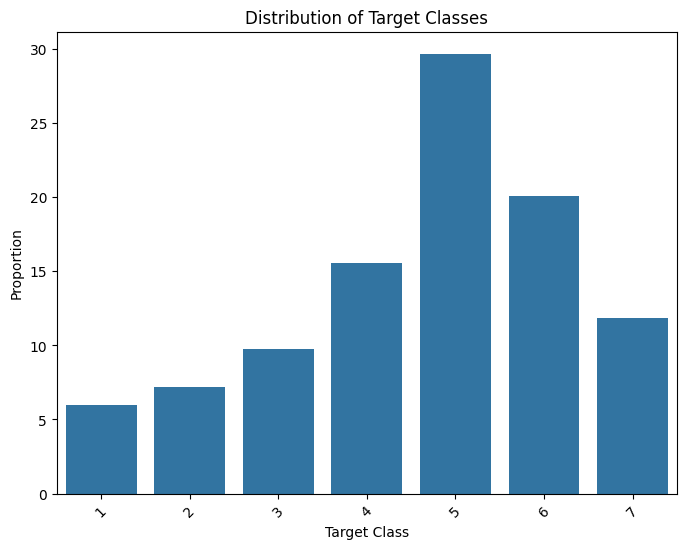

In [ ]:
# Check the percent of each class in the train data
target_counts = data_train['target'].value_counts().sort_index()
target_props = data_train['target'].value_counts(normalize=True).sort_index() * 100
target_data = pd.concat([target_counts, target_props], axis=1)
target_data.columns = ['Count', 'Proportion']
print(target_data)
# Using barplot to see the distribution of percentage of each class
plt.figure(figsize=(8, 6))
sns.barplot(x=target_data.index, y=target_data['Proportion'])
plt.xlabel('Target Class')
plt.ylabel('Proportion')
plt.title('Distribution of Target Classes')
plt.xticks(rotation=45)
plt.show()

**Observation** The distribution of target classes is not equally distribuuted with the most of it in 5th class (about 30%)

# Data Preprocessing

In [ ]:
# Treating missing values by imputing median value
imputer = SimpleImputer(strategy='median')
data_train['joint_torque_variance'] = imputer.fit_transform(data_train[['joint_torque_variance']])

In [ ]:
# Check again for any missing data in the training data
print("Missing values in the train data")
print(data_train.isnull().sum())

Missing values in the train data
row_id                      0
battery_health_pct          0
joint_torque_variance       0
vision_accuracy             0
task_completion_rate        0
error_count_7d              0
avg_cycle_time_sec          0
uptime_hrs                  0
last_maintenance_days       0
sensor_calibration_score    0
motor_temperature_c         0
load_capacity_pct           0
software_version            0
shift_hours_last_7d         0
self_diagnostic_score       0
motion_elegance_score       0
shift_reliability_index     0
target                      0
dtype: int64


In [ ]:
# Dropping the 'row_id' , 'shift_reliability_index' , 'motion_elegance_score' for training purposes.
data_train = data_train.drop(['row_id', 'shift_reliability_index', 'motion_elegance_score'], axis=1)

In [ ]:
# Seperate the 'row_id' column from the 'test_data' before putting the data into the model
data_test_id = data_test['row_id']
# Dropping the 'row_id', 'shift_reliability_index', 'motion_elegance_score' for putting data into model
data_test = data_test.drop(['row_id', 'shift_reliability_index', 'motion_elegance_score'], axis=1)

In [ ]:
# treating the missing value in the testing data by imputing median value
imputer = SimpleImputer(strategy='median')
data_test['joint_torque_variance'] = imputer.fit_transform(data_test[['joint_torque_variance']])

In [ ]:
# check again for any missing value in the test data '
print('Missing values in the testing data')
print(data_test.isnull().sum())

Missing values in the testing data
battery_health_pct          0
joint_torque_variance       0
vision_accuracy             0
task_completion_rate        0
error_count_7d              0
avg_cycle_time_sec          0
uptime_hrs                  0
last_maintenance_days       0
sensor_calibration_score    0
motor_temperature_c         0
load_capacity_pct           0
software_version            0
shift_hours_last_7d         0
self_diagnostic_score       0
dtype: int64


# Feature Engineering

In [ ]:
# Putting more feature engineering columns for better training
def engineer_features(df):
    df = df.copy()
    df['error_rate_per_hour'] = df['error_count_7d'] / df['shift_hours_last_7d'].replace(0, np.nan)
    df['error_rate_per_hour'] = df['error_rate_per_hour'].fillna(0)
    df['temp_load_ratio'] = df['motor_temperature_c'] / df['load_capacity_pct'].replace(0, np.nan)
    df['temp_load_ratio'] = df['temp_load_ratio'].fillna(df['temp_load_ratio'].median())
    df['diagnostic_gap'] = df['self_diagnostic_score'] - (df['sensor_calibration_score'] * 100)
    df['maintenance_risk'] = df['last_maintenance_days'] * df['error_count_7d']
    df['cycle_time_deviation'] = df['avg_cycle_time_sec'] - 8
    df['workload_intensity'] = df['uptime_hrs'] * df['shift_hours_last_7d']
    return df

data_train_feature_engineering = engineer_features(data_train)
data_test_feature_engineering = engineer_features(data_test)

# Define the feature columns based on the feature-engineered training data, excluding the 'target' column.
FEATURE_COLS = [c for c in data_train_feature_engineering.columns if c != 'target']

# Prepare the training features (X_all) and target (y_all)
X_all = data_train_feature_engineering[FEATURE_COLS]
y_all = data_train_feature_engineering['target']

# Prepare the test features (X_test)
# Ensure that the test data has the same columns as the training data features
X_test = data_test_feature_engineering[FEATURE_COLS]

# The test_ids were already extracted into data_test_id in a previous step.
test_ids = data_test_id


# Train all 5 models

# First model ( Light GBM )

In [ ]:
RANDOM_STATE = 42

# Define features (X) and target (y)
X = data_train.drop('target', axis=1)
y = data_train['target']

macro_f1_scorer = make_scorer(f1_score, average='macro')
param_grid = {
    'max_depth': [6, -1],
    'learning_rate': [0.05, 0.1],
}

print("\nTraining base models on base_train...")

lgb_m = lgb.LGBMClassifier(objective='multiclass', num_class=7, n_estimators=350, max_depth=6,
                            learning_rate=0.05, class_weight='balanced', random_state=RANDOM_STATE, verbose=-1)
lgb_m.fit(X_all, y_all)
print("  LightGBM done")

xgb_m = xgb.XGBClassifier(n_estimators=350, max_depth=6, learning_rate=0.05,
                           objective='multi:softprob', num_class=7, random_state=RANDOM_STATE, n_jobs=1)
xgb_m.fit(X_all, y_all - 1)
print("  XGBoost done")

cb_m = CatBoostClassifier(iterations=350, depth=6, learning_rate=0.05, loss_function='MultiClass',
                              auto_class_weights='Balanced', random_state=RANDOM_STATE, verbose=0, thread_count=1)
cb_m.fit(X_all, y_all)
print("  CatBoost done")

rf_m = RandomForestClassifier(n_estimators=250, max_depth=16, class_weight='balanced',
                               n_jobs=1, random_state=RANDOM_STATE)
rf_m.fit(X_all, y_all)
print("  RandomForest done")

et_m = ExtraTreesClassifier(n_estimators=250, max_depth=16, class_weight='balanced',
                             n_jobs=1, random_state=RANDOM_STATE)
et_m.fit(X_all, y_all)
print("  ExtraTrees done")

BASE_MODELS = {'lgb': lgb_m, 'xgb': xgb_m, 'cb': cb_m, 'rf': rf_m, 'et': et_m}

def get_all_probas(X_input):
    """Return dict of model_name -> (n_samples, 7) proba array, columns aligned to classes 1..7."""
    out = {}
    out['lgb'] = lgb_m.predict_proba(X_input)[:, np.argsort(lgb_m.classes_)]
    out['xgb'] = xgb_m.predict_proba(X_input)  # 0..6 already == class 1..7 order
    out['cb'] = cb_m.predict_proba(X_input)[:, np.argsort(cb_m.classes_)]
    out['rf'] = rf_m.predict_proba(X_input)[:, np.argsort(rf_m.classes_)]
    out['et'] = et_m.predict_proba(X_input)[:, np.argsort(et_m.classes_)]
    return out


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# Assign lgb_m to base_model for GridSearchCV
base_model = lgb_m

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring=macro_f1_scorer,
    cv=cv,
    n_jobs=1,
    verbose=2
)
print("\nRunning GridSearchCV (this may take a few minutes)...")
grid_search.fit(X, y)

print(f"\nBest Macro F1 (CV): {grid_search.best_score_:.4f}")
print(f"Best Params: {grid_search.best_params_}")


Training base models on base_train...
  LightGBM done
  XGBoost done
  CatBoost done
  RandomForest done
  ExtraTrees done

Running GridSearchCV (this may take a few minutes)...
Fitting 10 folds for each of 4 candidates, totalling 40 fits
[CV] END ....................learning_rate=0.05, max_depth=6; total time=  28.4s
[CV] END ....................learning_rate=0.05, max_depth=6; total time=  28.3s
[CV] END ....................learning_rate=0.05, max_depth=6; total time=  27.9s
[CV] END ....................learning_rate=0.05, max_depth=6; total time=  25.0s
[CV] END ....................learning_rate=0.05, max_depth=6; total time=  28.1s
[CV] END ....................learning_rate=0.05, max_depth=6; total time=  28.2s
[CV] END ....................learning_rate=0.05, max_depth=6; total time=  27.1s
[CV] END ....................learning_rate=0.05, max_depth=6; total time=  26.6s
[CV] END ....................learning_rate=0.05, max_depth=6; total time=  24.9s
[CV] END ....................le

**Refit on training data and predict on test**

In [ ]:
best_model = grid_search.best_estimator_
best_model.fit(X, y)
test_preds = best_model.predict(data_test)

# Build Submission file

In [ ]:
import os

submission = pd.DataFrame({
    'row_id': data_test_id,
    'target': test_preds
})

assert submission.shape[0] == 20000, "Submission must have exactly 20,000 rows"
assert set(submission['target'].unique()).issubset(set(range(1, 8))), "Target must be 1-7"

# Create the directory if it does not exist
output_dir = '/mnt/user-data/outputs'
os.makedirs(output_dir, exist_ok=True)

submission.to_csv(os.path.join(output_dir, 'submission.csv'), index=False)
print(f"\nSubmission saved: {submission.shape}")
print(submission.head())

In [ ]:
# Download the submission file as requested by the user
from google.colab import files
files.download('/mnt/user-data/outputs/submission.csv')